In [1]:
import pandas as pd
import numpy as np


from pathlib import Path
import pandas as pd

file_name = "diabetes.csv"

# Search upward from current working directory and find the file by name
csv_path = None
for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    matches = list(root.rglob(file_name))
    if matches:
        csv_path = matches[0]
        break

if csv_path is None:
    raise FileNotFoundError(f"{file_name} not found in workspace search.")

df = pd.read_csv(csv_path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)
y_pred[:5]

array([[0.72413777, 0.27586223],
       [0.81157946, 0.18842054],
       [0.88553428, 0.11446572],
       [0.83646086, 0.16353914],
       [0.52849806, 0.47150194]])

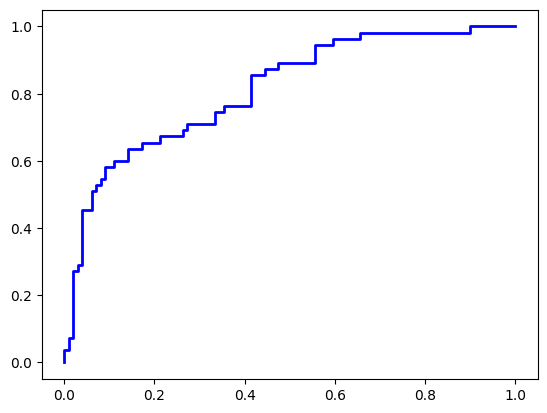

In [8]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred[:, 1])
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.show()